Confusion Matrix:
 [[55  8]
 [15 22]]

Accuracy: 0.77
Error Rate: 0.22999999999999998
Precision: 0.7333333333333333
Recall: 0.5945945945945946


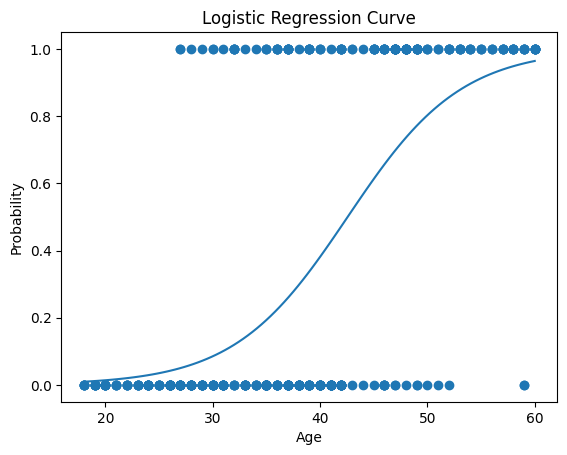

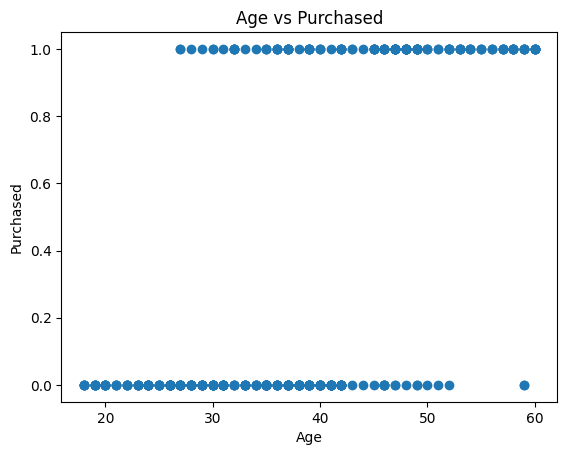

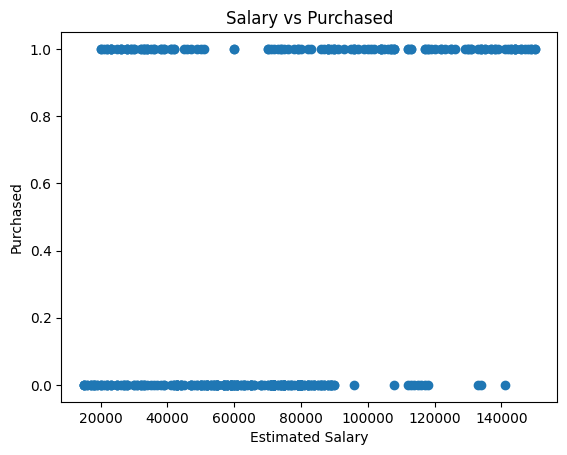

In [9]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# 2. LOAD DATA
df = pd.read_csv("Social_Network_Ads.csv")

# 3. PREPROCESSING
df = df.drop('User ID', axis=1)

# Features & Target (use .values to avoid warning)
X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

# 4. TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

# 5. SCALING
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# 6. MODEL
model = LogisticRegression()
model.fit(X_train, y_train)

# 7. PREDICTION
y_pred = model.predict(X_test)

# 8. CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

TN, FP, FN, TP = cm.ravel()

# 9. METRICS
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("\nAccuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

# ======================================
# 10. LOGISTIC CURVE (NO WARNING FIXED)
# ======================================
X_age = df[['Age']].values
y_age = df['Purchased'].values

model2 = LogisticRegression()
model2.fit(X_age, y_age)

X_curve = np.linspace(X_age.min(), X_age.max(), 100).reshape(-1, 1)
y_prob = model2.predict_proba(X_curve)[:, 1]

plt.scatter(X_age, y_age)
plt.plot(X_curve, y_prob)
plt.title("Logistic Regression Curve")
plt.xlabel("Age")
plt.ylabel("Probability")
plt.show()

# ======================================
# 11. EXTRA PLOT 1: AGE vs PURCHASED
# ======================================
plt.scatter(df['Age'], df['Purchased'])
plt.title("Age vs Purchased")
plt.xlabel("Age")
plt.ylabel("Purchased")
plt.show()

# ======================================
# 12. EXTRA PLOT 2: SALARY vs PURCHASED
# ======================================
plt.scatter(df['EstimatedSalary'], df['Purchased'])
plt.title("Salary vs Purchased")
plt.xlabel("Estimated Salary")
plt.ylabel("Purchased")
plt.show()

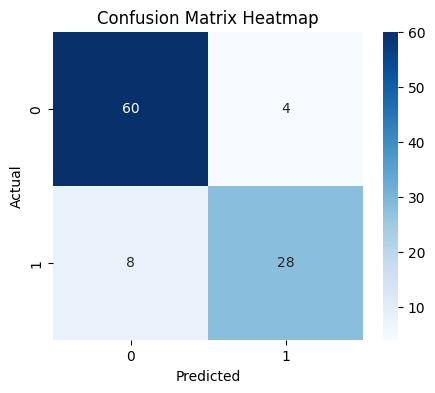

In [8]:
import seaborn as sns

# Plot heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()